<a href="https://colab.research.google.com/github/manuelabr241-eng/Simuladordecalcularuncredito/blob/main/S19_Analisis_Exploratorio_Portafolios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📝 Actividad de Evaluación: Análisis Exploratorio de Portafolios (10%)

**Instrucciones:**
1. Resuelve cada uno de los puntos solicitados utilizando código de Python limpio y ordenado.
2. No olvides acompañar cada visualización con su respectiva **interpretación analítica** (recuerda la regla de oro: qué observas y qué significa).
3. Puedes realizar esta actividad de forma individual o en parejas (según las indicaciones del docente).

---

## 🏦 Paso 1: Selección y Descarga de Datos

1. Selecciona **3 activos financieros** diferentes a los utilizados en la clase (evita usar AAPL, MSFT, GOOGL, AMZN o NVDA).
2. Descarga los datos históricos utilizando `yfinance` para el periodo del **1 de enero de 2024** al **1 de enero de 2026**.
3. Muestra las primeras 5 filas del DataFrame resultante para validar la descarga.

In [8]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Definir los tickers de los 3 activos seleccionados
tickers = ['ORCL', 'GE', 'PEP']

# Descargar los datos históricos desde el 1 de enero de 2024 al 1 de enero de 2026
datos = yf.download(tickers, start='2024-01-01', end='2026-01-01')

# Mostrar las primeras 5 filas del DataFrame resultante para validar la descarga
datos.head()

/tmp/ipykernel_724/1434373676.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(tickers, start='2024-01-01', end='2026-01-01')
[*********************100%***********************]  3 of 3 completed


Price            Close                                High              \
Ticker              GE        ORCL         PEP          GE        ORCL   
Date                                                                     
2024-01-02   98.875832  100.817947  156.347290  100.602925  101.418634   
2024-01-03   97.392113   99.267792  156.383484   98.302755  100.159127   
2024-01-04   97.863144   99.393730  155.045242   98.734537  100.139744   
2024-01-05   99.142738   99.529373  152.757599   99.181988  100.488527   
2024-01-08  100.704964  101.399261  152.911301  100.822727  101.505828   

Price                         Low                              Open  \
Ticker             PEP         GE       ORCL         PEP         GE   
Date                                                                  
2024-01-02  156.419629  98.318458  99.248424  152.983621  99.707975   
2024-01-03  158.417961  97.070244  98.570223  156.157431  98.224256   
2024-01-04  156.907917  97.478476  99.209655  154.240494  97.580525   
2024-01-05  155.135681  97.918070  99.103079  151.509782  98.051526   
2024-01-08  153.471908  97.509855  98.948079  151.717734  99.087784   

Price                                Volume                    
Ticker            ORCL         PEP       GE     ORCL      PEP  
Date                                                           
2024-01-02  101.263615  153.282012  5189425  9597500  5743100  
2024-01-03  100.081625  158.237121  4531850  9455600  5588200  
2024-01-04   99.568122  155.171831  4364199  6822300  6283200  
2024-01-05   99.335600  155.135681  4190157  6133800  5252500  
2024-01-08   99.732848  152.757586  6920068  7038700  5735600

## 📈 Paso 2: Análisis de Precios de Cierre y Normalización

1. Filtra y extrae únicamente los precios de cierre (`Close`).
2. Grafica en una sola figura la evolución temporal de los precios originales de tus 3 activos.
3. Realiza la normalización (base 100 en el primer registro) y grafica nuevamente las series en otra figura.

### 💬 Pregunta de interpretación #1:
Al comparar ambos gráficos (precios reales vs. precios normalizados), ¿por qué es metodológicamente más correcto utilizar el gráfico normalizado para comparar el rendimiento histórico de los activos? Explica la diferencia en el comportamiento visual observado.

A simple vista se ven muy similares, pero cuando se analiza detalladamente se puede notar que si se ven ciertas diferencias. Es más correcto utilizar el grafico normalizado ya que ahí se puede saber el riesgo que puede correr.En la parte de ORCL se puede evidenciar que en las dos gráficas todo permanece totalmente igual, en GE permanece igual en las dos graficas desde el 2025/01 en las otras fechas si varia y en el PEP se puede ver que en el grafico normalizado siempre permanece por debajo.

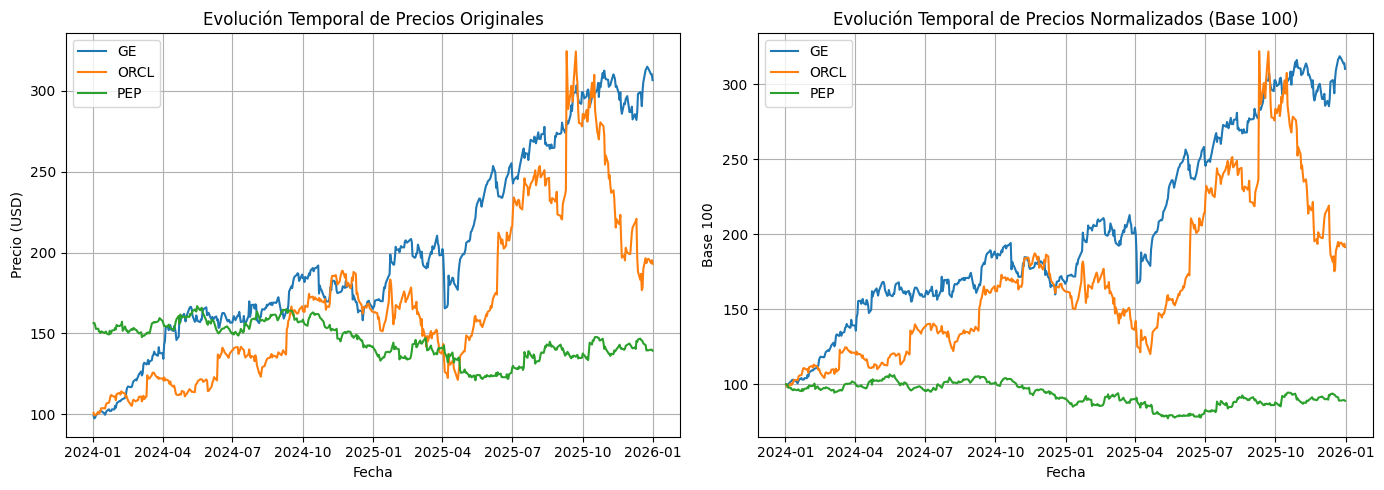

In [9]:
# 1. Filtrar y extraer únicamente los precios de cierre (Close) eliminando MultiIndex de raíz
precios_originales = datos['Close']
datos_planos = {}

for ticker in ['GE', 'ORCL', 'PEP']:
    datos_planos[ticker] = precios_originales[ticker].to_numpy().ravel().astype(float)

precios_cierre = pd.DataFrame(datos_planos, index=precios_originales.index)

# Configurar las figuras de los gráficos
plt.figure(figsize=(14, 5))

# 2. Graficar precios originales
plt.subplot(1, 2, 1)
for ticker in precios_cierre.columns:
    plt.plot(precios_cierre.index, precios_cierre[ticker], label=ticker)
plt.title('Evolución Temporal de Precios Originales')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True)

# 3. Realizar la normalización (Base 100 en el primer registro) y graficar
precios_normalizados = (precios_cierre / precios_cierre.iloc[0]) * 100

plt.subplot(1, 2, 2)
for ticker in precios_normalizados.columns:
    plt.plot(precios_normalizados.index, precios_normalizados[ticker], label=ticker)
plt.title('Evolución Temporal de Precios Normalizados (Base 100)')
plt.xlabel('Fecha')
plt.ylabel('Base 100')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

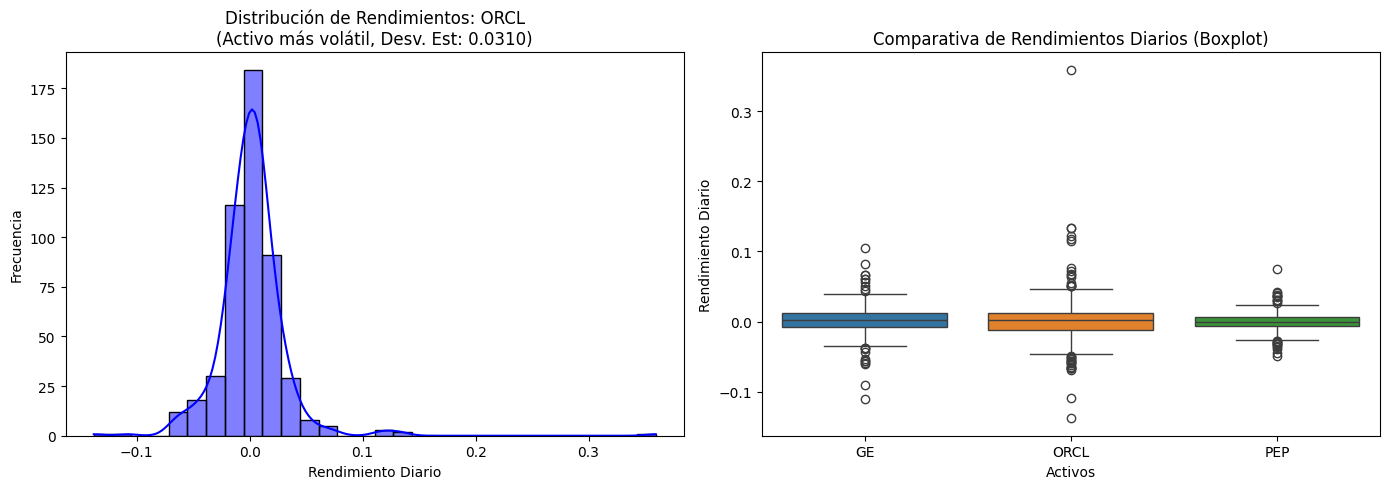

In [10]:
# 1. Extraer los precios de cierre limpios y crear un DataFrame plano sin MultiIndex
precios_originales = datos['Close']
datos_limpios = {}

for ticker in ['GE', 'ORCL', 'PEP']:
    # Extraemos solo los números planos utilizando to_numpy y ravel para garantizar un arreglo 1D puro
    datos_limpios[ticker] = precios_originales[ticker].to_numpy().ravel().astype(float)

# Construimos un nuevo DataFrame con un índice de columnas plano (índice simple de strings)
precios_limpios = pd.DataFrame(datos_limpios, index=precios_originales.index)

# Calcular rendimientos diarios de los activos y eliminar valores nulos (NaN)
rendimientos = precios_limpios.pct_change().dropna()

# Identificar el activo más volátil según su desviación estándar
activo_mas_volatil = rendimientos.std().idxmax()
std_maxima = rendimientos.std().max()

# Configuración de figuras
plt.figure(figsize=(14, 5))

# 2. Histograma con el activo más volátil
plt.subplot(1, 2, 1)
sns.histplot(rendimientos[activo_mas_volatil], kde=True, color='blue', bins=30)
plt.title(f'Distribución de Rendimientos: {activo_mas_volatil}\n(Activo más volátil, Desv. Est: {std_maxima:.4f})')
plt.xlabel('Rendimiento Diario')
plt.ylabel('Frecuencia')

# 3. Boxplot comparativo de rendimientos diarios
plt.subplot(1, 2, 2)
sns.boxplot(data=rendimientos)
plt.title('Comparativa de Rendimientos Diarios (Boxplot)')
plt.ylabel('Rendimiento Diario')
plt.xlabel('Activos')

plt.tight_layout()
plt.show()

## 📊 Paso 4: Asociación y Correlación

1. Calcula la matriz de correlación de Pearson para los rendimientos de tus 3 activos.
2. Grafica un **mapa de calor (Heatmap)**.

### 💬 Pregunta de interpretación #3:
- ¿Existe alguna correlación fuerte (cercana a 1 o -1) entre alguno de tus activos?
No. Ninguno de los pares de activos muestra una correlación fuerte (valores mayores a 0.7 o menores a -0.7).
La relación más alta observada es entre GE y ORCL (0.3282), la cual es una correlación positiva moderada o baja. Esto indica que los rendimientos de estas dos empresas tienden a moverse en la misma dirección en cierta medida, pero no de forma dependiente.

- Si tuvieras que armar un portafolio de inversión buscando la **diversificación** (minimizar el riesgo conjunto), ¿qué par de activos elegirías de acuerdo a tus resultados y por qué?
Para conformar un portafolio buscando la máxima reducción de riesgo, elegiría la combinación de GE y PEP o ORCL y PEP. Esto se debe a que su correlación es ligeramente negativa (-0.0781), lo que indica que sus rendimientos diarios se mueven de manera prácticamente independiente. Según la Teoría Moderna de Portafolios, combinar activos con correlaciones nulas o negativas permite compensar las fluctuaciones individuales y reducir la volatilidad total del portafolio.

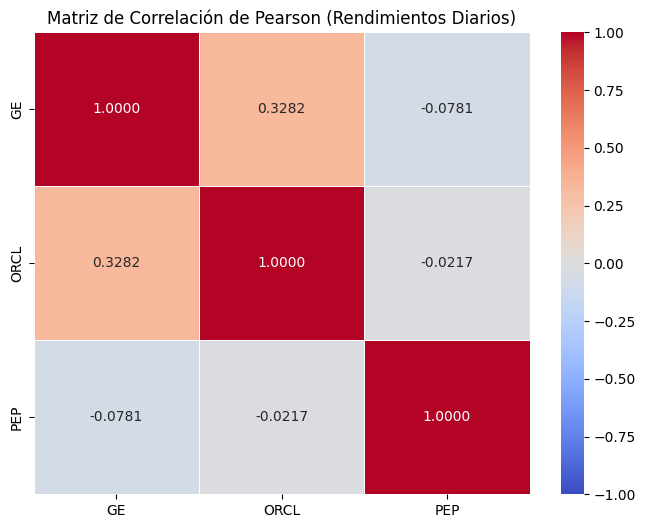

In [11]:
# 1. Calcular matriz de correlación de Pearson sobre los rendimientos calculados
correlacion = rendimientos.corr()

# 2. Dibujar el Heatmap utilizando Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(correlacion, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".4f", linewidths=0.5)
plt.title('Matriz de Correlación de Pearson (Rendimientos Diarios)')
plt.show()

## 🧮 Paso 5: Estadísticas Descriptivas y Conclusión

1. Genera un DataFrame de resumen estadístico que incluya para cada activo: Media, Mediana, Desviación Estándar, Mínimo y Máximo de los rendimientos diarios.
2. Escribe una breve conclusión final dirigida a un inversionista ficticio, interpretando los estadísticos clave obtenidos.

In [12]:
# Generar resumen de estadísticas descriptivas (Media, Mediana, Desviación estándar, Mínimo y Máximo)
# Nota: Asegúrate de haber calculado la variable 'rendimientos' en el Paso 3 antes de ejecutar esta celda.
try:
    # pandas.describe() calcula automáticamente la media, desviación estándar, mínimo, máximo y percentiles (incluida la mediana en 50%)
    resumen = rendimientos.describe().loc[['mean', '50%', 'std', 'min', 'max']]
    resumen.index = ['Media', 'Mediana (50%)', 'Desviación Estándar', 'Mínimo', 'Máximo']
    display(resumen)

,GE,ORCL,PEP
Media,0.002446,0.001750,-0.000154
Mediana (50%),0.002718,0.001991,-0.000538
Desviación Estándar,0.019161,0.030972,0.012438
Mínimo,-0.110963,-0.137909,-0.048854
Máximo,0.105686,0.359488,0.074547
